In [2]:
import pandas as pd

df = pd.read_csv('./Sleep_health_and_lifestyle_dataset.csv')
display(df.head())
df.info()
df.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


In [3]:
# Check missing values and unique values in each column
missing = df.isnull().sum()
unique = df.nunique()

# Display missing and unique values
print('Missing values per column:')
print(missing)
print('\nUnique values per column:')
print(unique)

# Show value counts for Sleep Disorder
print('\nSleep Disorder value counts:')
print(df['Sleep Disorder'].value_counts(dropna=False))

Missing values per column:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Unique values per column:
Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 4
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               2
dtype: int64

Sleep Disorder value counts:
Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count,

In [4]:
# Fill missing 'Sleep Disorder' with 'No Disorder'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
cat_cols = ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le

# Display first few rows to verify encoding
display(df.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Gender_enc,Occupation_enc,BMI Category_enc,Blood Pressure_enc,Sleep Disorder_enc
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,1,9,3,11,1
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,1,1,0,9,1
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,1,1,0,9,1
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1,6,2,22,2
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1,6,2,22,2


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Gender_enc,Occupation_enc,BMI Category_enc,Blood Pressure_enc,Sleep Disorder_enc
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374,374.000000,374.000000,374.000000,374.000000,374.000000
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,No Disorder,NaN,NaN,NaN,NaN,NaN
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,219,NaN,NaN,NaN,NaN,NaN
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN,0.505348,3.772727,1.296791,13.114973,1.002674
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN,0.500641,3.056081,1.431226,7.100590,0.644626
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN,0.000000,1.000000,0.000000,9.000000,1.000000
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN,1.000000,3.000000,0.000000,15.000000,1.000000
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN,1.000000,5.000000,3.000000,20.000000,1.000000


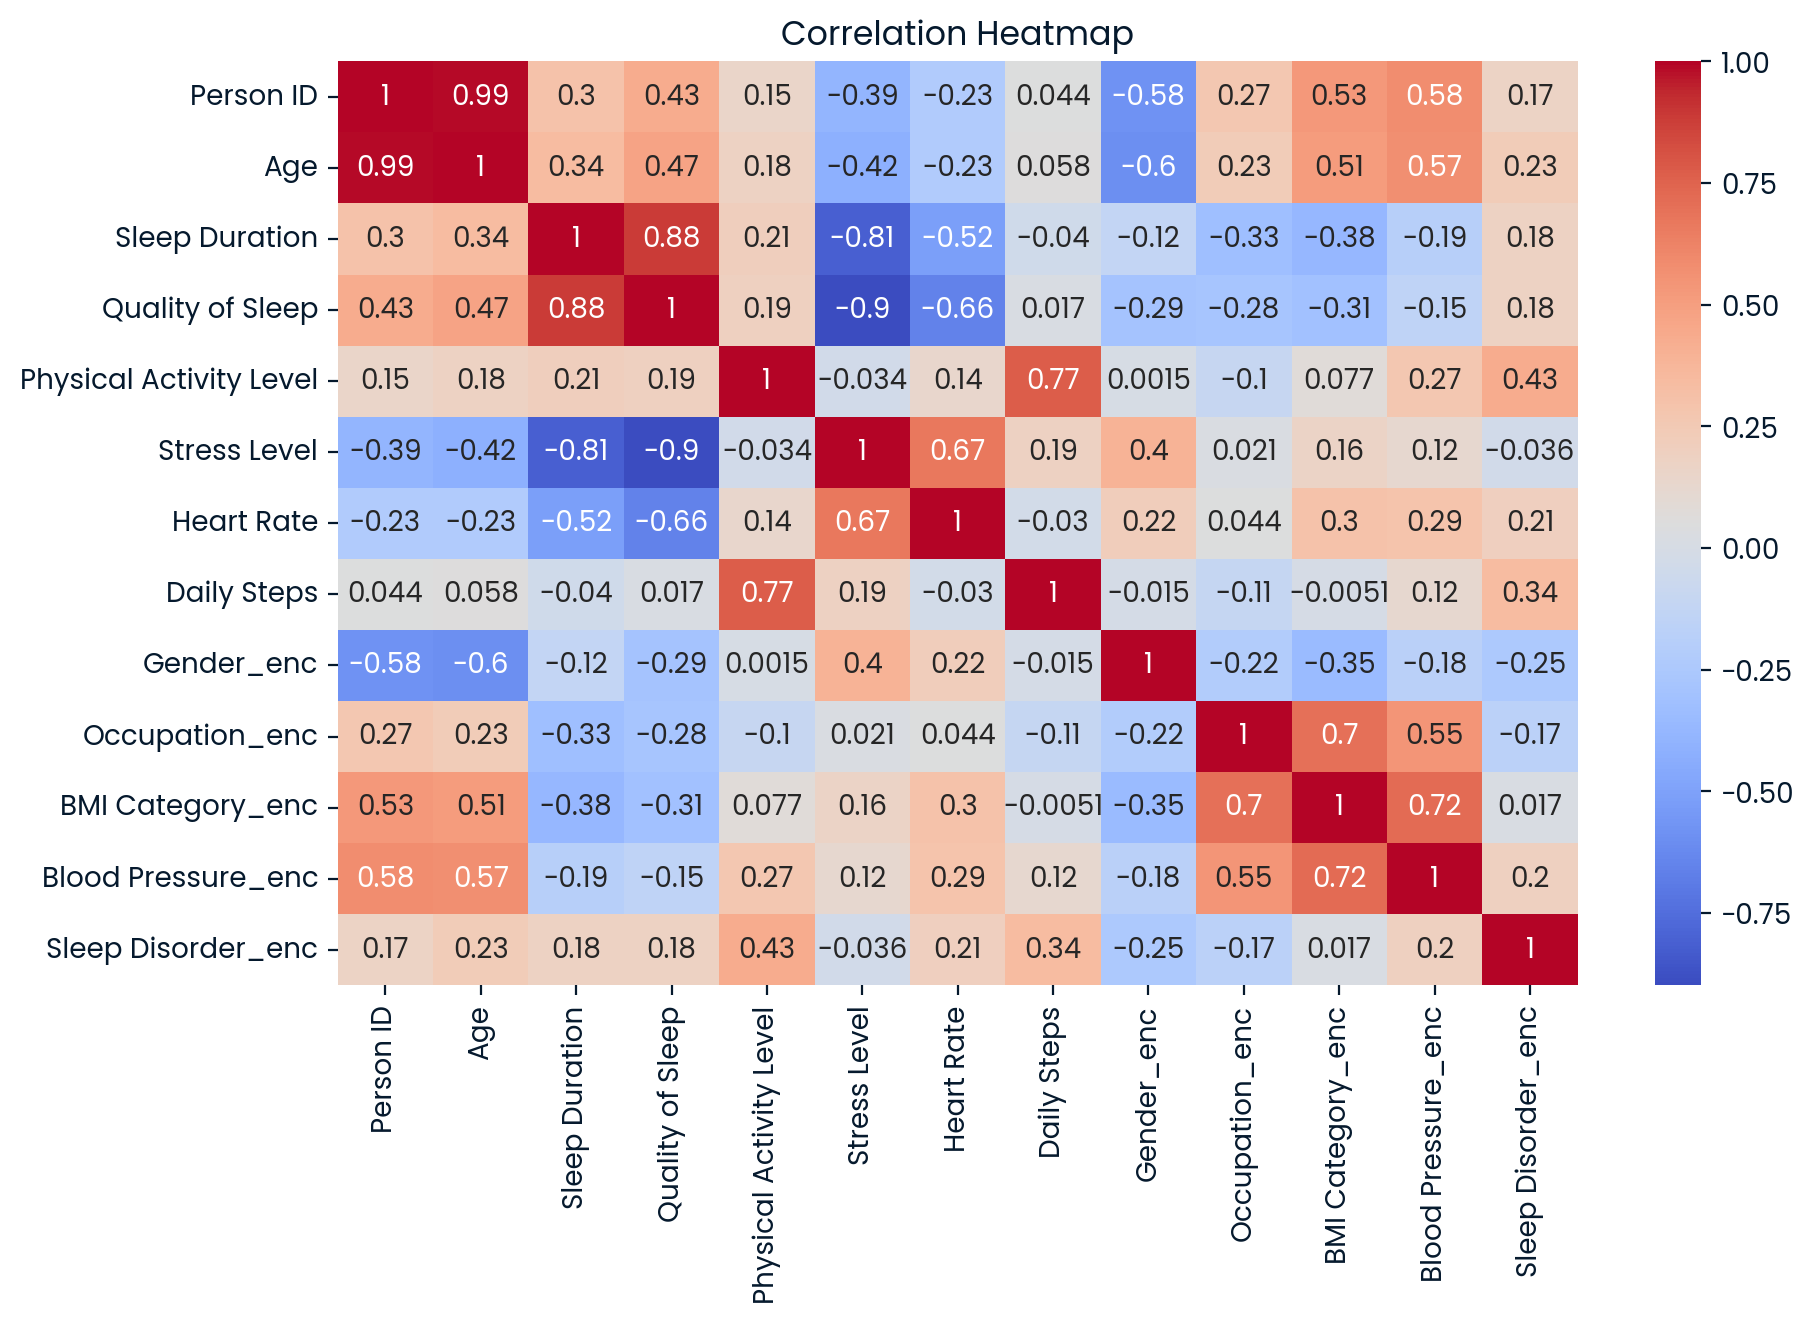

In [5]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Summary statistics
display(df.describe(include='all'))

# Distribution of Sleep Disorder
fig1 = px.histogram(df, x='Sleep Disorder', title='Distribution of Sleep Disorder')
fig1.show()

# Distribution of Sleep Duration by Sleep Disorder
fig2 = px.box(df, x='Sleep Disorder', y='Sleep Duration', title='Sleep Duration by Sleep Disorder')
fig2.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [6]:
# Load the dataset
file_path = './Sleep_health_and_lifestyle_dataset.csv'
df = pd.read_csv(file_path)

# Check for missing values
display(df.isnull().sum())

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler
cat_cols = ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le

# Scale numerical features
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

display(df.head())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Gender_enc,Occupation_enc,BMI Category_enc,Blood Pressure_enc,Sleep Disorder_enc
0,1,Male,-1.753096,Software Engineer,-1.298887,-1.098280,-0.825418,0.347021,Overweight,126/83,1.654719,-1.619584,NaN,1,9,3,11,2
1,2,Male,-1.637643,Doctor,-1.173036,-1.098280,0.039844,1.475592,Normal,125/80,1.170474,1.970077,NaN,1,1,0,9,2
2,3,Male,-1.637643,Doctor,-1.173036,-1.098280,0.039844,1.475592,Normal,125/80,1.170474,1.970077,NaN,1,1,0,9,2
3,4,Male,-1.637643,Sales Representative,-1.550588,-2.771424,-1.402260,1.475592,Obese,140/90,3.591698,-2.362273,Sleep Apnea,1,6,2,22,1
4,5,Male,-1.637643,Sales Representative,-1.550588,-2.771424,-1.402260,1.475592,Obese,140/90,3.591698,-2.362273,Sleep Apnea,1,6,2,22,1


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define features and target
target = 'Sleep Disorder_enc'
features = ['Gender_enc', 'Age', 'Occupation_enc', 'Sleep Duration', 'Quality of Sleep',
            'Physical Activity Level', 'Stress Level', 'BMI Category_enc', 'Blood Pressure_enc',
            'Heart Rate', 'Daily Steps']

# Drop rows with missing target values
model_df = df.dropna(subset=['Sleep Disorder'])

X = model_df[features]
y = model_df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

display(report)
display(cm)

{'0': {'precision': 0.875,
  'recall': 0.9333333333333333,
  'f1-score': 0.9032258064516129,
  'support': 15.0},
 '1': {'precision': 0.9333333333333333,
  'recall': 0.875,
  'f1-score': 0.9032258064516129,
  'support': 16.0},
 'accuracy': 0.9032258064516129,
 'macro avg': {'precision': 0.9041666666666667,
  'recall': 0.9041666666666667,
  'f1-score': 0.9032258064516129,
  'support': 31.0},
 'weighted avg': {'precision': 0.9051075268817205,
  'recall': 0.9032258064516129,
  'f1-score': 0.9032258064516129,
  'support': 31.0}}

array([[14,  1],
       [ 2, 14]])

In [8]:
import plotly.graph_objects as go

# Get feature importances
importances = rf.feature_importances_
feature_names = features

# Sort features by importance
indices = importances.argsort()[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot feature importances
fig = go.Figure(go.Bar(x=sorted_importances, y=sorted_features, orientation='h'))
fig.update_layout(title='Feature Importance for Sleep Disorder Prediction',
                  xaxis_title='Importance', yaxis_title='Feature', yaxis=dict(autorange='reversed'))
fig.show()

In [9]:
import plotly.express as px

# Identify the most important feature
top_feature = sorted_features[0]

# Plot distribution of the top feature by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y=top_feature, color='Sleep Disorder',
             title=f'Distribution of {top_feature} by Sleep Disorder Status')
fig.show()

In [10]:
# Plot distribution of stress level by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y='Stress Level', color='Sleep Disorder',
             title='Distribution of Stress Level by Sleep Disorder Status')
fig.show()

In [11]:
# Plot distribution of physical activity level by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y='Physical Activity Level', color='Sleep Disorder',
             title='Distribution of Physical Activity Level by Sleep Disorder Status')
fig.show()

In [12]:
import plotly.express as px

# Plot count of sleep disorder status by BMI category
fig = px.histogram(model_df, x='BMI Category', color='Sleep Disorder', barmode='group',
                   title='Sleep Disorder Status by BMI Category')
fig.show()

In [13]:
# Plot distribution of age by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y='Age', color='Sleep Disorder',
             title='Distribution of Age by Sleep Disorder Status')
fig.show()

In [14]:
# Plot count of sleep disorder status by gender
fig = px.histogram(model_df, x='Gender', color='Sleep Disorder', barmode='group',
                   title='Sleep Disorder Status by Gender')
fig.show()

In [15]:
# Plot distribution of physical activity level by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y='Physical Activity Level', color='Sleep Disorder',
             title='Physical Activity Level by Sleep Disorder Status')
fig.show()

In [16]:
# Plot distribution of stress level by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y='Stress Level', color='Sleep Disorder',
             title='Stress Level by Sleep Disorder Status')
fig.show()

In [17]:
# Plot count of sleep disorder status by BMI category
fig = px.histogram(model_df, x='BMI Category', color='Sleep Disorder', barmode='group',
                   title='Sleep Disorder Status by BMI Category')
fig.show()

In [18]:
# Box plot of sleep duration by sleep disorder status
import plotly.express as px
fig = px.box(model_df, x='Sleep Disorder', y='Sleep Duration', color='Sleep Disorder',
             title='Sleep Duration by Sleep Disorder Status')
fig.show()

In [19]:
# Box plot of stress level by sleep disorder status
fig = px.box(model_df, x='Sleep Disorder', y='Stress Level', color='Sleep Disorder',
             title='Stress Level by Sleep Disorder Status')
fig.show()

In [31]:
# Calculate average sleep duration by physical activity level
avg_sleep_by_activity = df.groupby('Physical Activity Level')['Sleep Duration'].mean().reset_index()

# Plot
fig = px.bar(avg_sleep_by_activity, x='Physical Activity Level', y='Sleep Duration',
             title='Average Sleep Duration by Physical Activity Level',
             labels={'Sleep Duration': 'Average Sleep Duration (hours)'})
fig.show()

In [32]:
# Count of sleep disorders by BMI category
sleep_disorder_by_bmi = df.groupby(['BMI Category', 'Sleep Disorder']).size().reset_index(name='Count')

# Plot
fig = px.bar(sleep_disorder_by_bmi, x='BMI Category', y='Count', color='Sleep Disorder',
             title='Distribution of Sleep Disorders by BMI Category',
             barmode='group')
fig.show()

In [33]:
# Count of sleep disorders by gender
sleep_disorder_by_gender = df.groupby(['Gender', 'Sleep Disorder']).size().reset_index(name='Count')

# Plot
fig = px.bar(sleep_disorder_by_gender, x='Gender', y='Count', color='Sleep Disorder',
             title='Distribution of Sleep Disorders by Gender',
             barmode='group')
fig.show()

In [34]:
# Scatter plot of Stress Level vs Quality of Sleep
fig = px.scatter(df, x='Stress Level', y='Quality of Sleep',
                 title='Stress Level vs Quality of Sleep',
                 trendline='ols',
                 labels={'Stress Level': 'Stress Level', 'Quality of Sleep': 'Quality of Sleep'})
fig.show()

In [35]:
# Calculate average sleep duration by physical activity level
avg_sleep_by_activity = df.groupby('Physical Activity Level')['Sleep Duration'].mean().reset_index()

# Plot
fig = px.bar(avg_sleep_by_activity, x='Physical Activity Level', y='Sleep Duration',
             title='Average Sleep Duration by Physical Activity Level',
             labels={'Sleep Duration': 'Average Sleep Duration (hours)', 'Physical Activity Level': 'Physical Activity Level'})
fig.show()

In [36]:
# Count of sleep disorders by BMI category
sleep_bmi_counts = df.groupby(['BMI Category', 'Sleep Disorder']).size().reset_index(name='Count')

# Plot grouped bar chart
fig = px.bar(sleep_bmi_counts, x='BMI Category', y='Count', color='Sleep Disorder', barmode='group',
             title='Distribution of Sleep Disorders by BMI Category',
             labels={'Count': 'Number of Individuals', 'BMI Category': 'BMI Category'})
fig.show()

In [37]:
# Count of sleep disorders by BMI category
disorder_bmi_counts = df.groupby(['BMI Category', 'Sleep Disorder']).size().reset_index(name='Count')

# Plot grouped bar chart
fig = px.bar(disorder_bmi_counts, x='BMI Category', y='Count', color='Sleep Disorder',
             barmode='group',
             title='Distribution of Sleep Disorders by BMI Category',
             labels={'Count': 'Number of Cases', 'BMI Category': 'BMI Category'})
fig.show()

In [38]:
# Scatter plot of daily steps vs heart rate
fig = px.scatter(df, x='Daily Steps', y='Heart Rate',
                 title='Daily Steps vs Heart Rate',
                 labels={'Daily Steps': 'Daily Steps', 'Heart Rate': 'Heart Rate (bpm)'})
fig.show()

In [39]:
# Box plot of sleep duration by occupation
fig = px.box(df, x='Occupation', y='Sleep Duration',
             title='Sleep Duration by Occupation',
             labels={'Sleep Duration': 'Sleep Duration (hours)', 'Occupation': 'Occupation'})
fig.update_xaxes(tickangle=45)
fig.show()

In [40]:
# Calculate average quality of sleep by sleep disorder
avg_quality = df.groupby('Sleep Disorder')['Quality of Sleep'].mean().reset_index()

# Bar plot
fig = px.bar(avg_quality, x='Sleep Disorder', y='Quality of Sleep',
             title='Average Quality of Sleep by Sleep Disorder',
             labels={'Quality of Sleep': 'Average Quality of Sleep', 'Sleep Disorder': 'Sleep Disorder'})
fig.show()

In [41]:
# Scatter plot of age vs sleep duration
fig = px.scatter(df, x='Age', y='Sleep Duration',
                 title='Sleep Duration vs Age',
                 labels={'Age': 'Age (years)', 'Sleep Duration': 'Sleep Duration (hours)'},
                 trendline='ols')
fig.show()

In [42]:
# Count of sleep disorders by BMI category
bmi_sleep = df.groupby(['BMI Category', 'Sleep Disorder']).size().reset_index(name='Count')

# Stacked bar plot
fig = px.bar(bmi_sleep, x='BMI Category', y='Count', color='Sleep Disorder',
             title='Distribution of Sleep Disorders by BMI Category',
             labels={'Count': 'Number of Individuals', 'BMI Category': 'BMI Category'})
fig.show()

In [43]:
# Count of sleep disorders by gender
gender_sleep = df.groupby(['Gender', 'Sleep Disorder']).size().reset_index(name='Count')

# Bar plot
fig = px.bar(gender_sleep, x='Gender', y='Count', color='Sleep Disorder',
             barmode='group',
             title='Prevalence of Sleep Disorders by Gender',
             labels={'Count': 'Number of Individuals', 'Gender': 'Gender'})
fig.show()

In [44]:
# Calculate average sleep quality by physical activity level
activity_sleep = df.groupby('Physical Activity Level')['Quality of Sleep'].mean().reset_index()

# Line plot
fig = px.line(activity_sleep, x='Physical Activity Level', y='Quality of Sleep',
              markers=True,
              title='Average Sleep Quality by Physical Activity Level',
              labels={'Quality of Sleep': 'Average Sleep Quality', 'Physical Activity Level': 'Physical Activity Level'})
fig.show()

In [45]:
# Scatter plot of daily steps vs sleep duration
fig = px.scatter(df, x='Daily Steps', y='Sleep Duration',
                 trendline='ols',
                 title='Relationship Between Daily Steps and Sleep Duration',
                 labels={'Daily Steps': 'Daily Steps', 'Sleep Duration': 'Sleep Duration (hours)'})
fig.show()

In [46]:
# Count of sleep disorders by BMI category
bmi_sleep_disorder = df.groupby(['BMI Category', 'Sleep Disorder']).size().reset_index(name='Count')

# Bar plot
fig = px.bar(bmi_sleep_disorder, x='BMI Category', y='Count', color='Sleep Disorder',
             barmode='group',
             title='Distribution of Sleep Disorders by BMI Category',
             labels={'Count': 'Number of Individuals', 'BMI Category': 'BMI Category'})
fig.show()

In [48]:
# Box plot of sleep quality by occupation, ordered by mean sleep quality
fig = px.box(df, x='Occupation', y='Quality of Sleep',
             title='Sleep Quality by Occupation',
             labels={'Quality of Sleep': 'Quality of Sleep (1=Poor, 10=Excellent)', 'Occupation': 'Occupation'})
fig.update_xaxes(categoryorder='mean descending', title='Occupation')
fig.show()

In [49]:
# Scatter plot of age vs sleep duration with trendline
fig = px.scatter(df, x='Age', y='Sleep Duration', trendline='ols',
                 title='Relationship Between Age and Sleep Duration',
                 labels={'Age': 'Age', 'Sleep Duration': 'Sleep Duration (hours)'})
fig.show()

In [50]:
# Histogram of sleep duration by sleep disorder status
fig = px.histogram(df, x='Sleep Duration', color='Sleep Disorder', barmode='overlay',
                   title='Sleep Duration Distribution by Sleep Disorder Status',
                   labels={'Sleep Duration': 'Sleep Duration (hours)', 'Sleep Disorder': 'Sleep Disorder'})
fig.show()

In [51]:
# Calculate average physical activity level by sleep disorder category
activity_by_disorder = df.groupby('Sleep Disorder')['Physical Activity Level'].mean().reset_index()
activity_by_disorder

,Sleep Disorder,Physical Activity Level
0,Insomnia,46.818182
1,Sleep Apnea,74.794872


In [52]:
import plotly.express as px
import pandas as pd

df = pd.read_csv('./Sleep_health_and_lifestyle_dataset.csv')

# 1. Average stress level by sleep disorder
stress_by_disorder = df.groupby('Sleep Disorder')['Stress Level'].mean().reset_index()

# 2. Average daily steps by sleep disorder
steps_by_disorder = df.groupby('Sleep Disorder')['Daily Steps'].mean().reset_index()

# 3. Average heart rate by sleep disorder
hr_by_disorder = df.groupby('Sleep Disorder')['Heart Rate'].mean().reset_index()

# 4. BMI category distribution by sleep disorder
bmi_disorder_fig = px.bar(
    df.groupby(['Sleep Disorder', 'BMI Category']).size().reset_index(name='Count'),
    x='Sleep Disorder', y='Count', color='BMI Category', barmode='group',
    title='BMI Category Distribution by Sleep Disorder')

# 5. Gender differences in sleep disorders
gender_disorder_fig = px.bar(
    df.groupby(['Sleep Disorder', 'Gender']).size().reset_index(name='Count'),
    x='Sleep Disorder', y='Count', color='Gender', barmode='group',
    title='Gender Differences in Sleep Disorders')

from IPython.display import display

display(stress_by_disorder, steps_by_disorder, hr_by_disorder)
bmi_disorder_fig.show()
gender_disorder_fig.show()

,Sleep Disorder,Stress Level
0,Insomnia,5.870130
1,Sleep Apnea,5.666667


,Sleep Disorder,Daily Steps
0,Insomnia,5901.298701
1,Sleep Apnea,7619.230769


,Sleep Disorder,Heart Rate
0,Insomnia,70.467532
1,Sleep Apnea,73.089744
